# **Course 3 Automatidata project**
**Course 3 - Go Beyond the Numbers: Translate Data into Insights**

You are the newest data professional in a fictional data consulting firm: Automatidata. The team is in an early stage of the project, having only just completed an initial plan of action and some early Python coding work. 

Luana Rodriquez, the senior data analyst at Automatidata, is pleased with the work you have already completed and requests your assistance with some EDA and data visualization work for the New York City Taxi and Limousine Commission project (New York City TLC) to get a general understanding of what taxi ridership looks like. The management team is asking for a Python notebook showing data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help understand the data. At the very least, include a box plot of the ride durations and some time series plots, like a breakdown by quarter or month. 

Additionally, the management team has recently asked all EDA to include Tableau visualizations. For this taxi data, create a Tableau dashboard showing a New York City map of taxi/limo trips by month. Make sure it is easy to understand to someone who isn’t data savvy, and remember that the assistant director at the New York City TLC is a person with visual impairments.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

### Course 3 End-of-course project: Exploratory data analysis

In this activity, you will examine data provided and prepare it for analysis. You will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs. 

Please note that the Tableau visualization activity is optional, and will not affect your completion of the course. Completing the Tableau activity will help you practice planning out and plotting a data visualization based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C2 and perform further EDA on this data with the aim of learning more about the variables. 
  
**The goal** is to clean data set and create a visualization.
<br/>  
*This activity has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Building visualizations

**Part 4:** Evaluate and share results

<br/> 
Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work. 



# **Visualize a story in Tableau and Python**

# **PACE stages** 


<img src="images/Pace.png" width="100" height="100" align=left>

   *        [Plan](#scrollTo=psz51YkZVwtN&line=3&uniqifier=1)
   *        [Analyze](#scrollTo=mA7Mz_SnI8km&line=4&uniqifier=1)
   *        [Construct](#scrollTo=Lca9c8XON8lc&line=2&uniqifier=1)
   *        [Execute](#scrollTo=401PgchTPr4E&line=2&uniqifier=1)

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: Plan 

In this stage, consider the following questions where applicable to complete your code response:
1. Identify any outliers: 


*   What methods are best for identifying outliers?
*   How do you make the decision to keep or exclude outliers from any future models?



**Answers:**

Outliers, in particular global outliers, can be identified visually by plotting the data. Some structuring of the data might be needed to identify contextual outliers.

Alternatively, for numerical variables, outliers can be identified by filtering for values that are outside of the boundaries set by Q1 - 1.5\*IQR and Q3 + 1.5\*IQR

The decision of how to handle outliers must be made on a dataset-by-dataset basis. Outliers can be either removed, or set to the closest value of chosen boundaries, or they can be kept. In any case, the handling of outliers must consider the ethical implications of how the data is modified by the chosen method.

### Task 1. Imports, links, and loading
Go to Tableau Public
The following link will help you complete this activity. Keep Tableau Public open as you proceed to the next steps. 

Link to supporting materials: 
Tableau Public: https://public.tableau.com/s/ 

For EDA of the data, import the data and packages that would be most helpful, such as pandas, numpy and matplotlib. 


In [1]:
# Import packages and libraries
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into dataframe
df = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: Analyze 

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### Task 2a. Data exploration and cleaning

Decide which columns are applicable

The first step is to assess your data. Check the Data Source page on Tableau Public to get a sense of the size, shape and makeup of the data set. Then answer these questions to yourself: 

Given our scenario, which data columns are most applicable? 
Which data columns can I eliminate, knowing they won’t solve our problem scenario? 

Consider functions that help you understand and structure the data. 

*    head()
*    describe()
*    info()
*    groupby()
*    sortby()

What do you do about missing data (if any)? 

Are there data outliers? What are they and how might you handle them? 

What do the distributions of your variables tell you about the question you're asking or the problem you're trying to solve?




### **Answers:**

**1. Data columns**

The most relevent columns are the following:
- tpep_pickup_datetime
- tpep_dropoff_datetime
- passenger_count
- trip_distance
- RatecodeID
- PULocationID
- DOLocationID
- payment_type
- fare_amount

The other columns are not relevant to the goal of the project, which is to predict the fare amount. Therefore:
The first column (unnamed) which contains the record id, as well as the VendorID are not useful for the analysis. Also, the store_and_fwd_flag contains technical information that is not relevant. Finally, the amounts that are on top of the fare amount, as well as the total amount, are not relevant, since the goal is to predict the fare amount.

However, the additional amounts apart from the tip amount (i.e. extra, mta_tax, tolls_amount, improvement_surcharge) could be incorporated into the app that estimates the taxi fares in order to provide an estimation of the total amount (excluding tip) that customers will likely have to pay. Since these additional amounts are fixed according to known factors, they can be easily calculated given the parameters of the trip that the customer plans to do.

**2. Missing data and outliers**

There are no missing values.

There is one extreme fare amount (999.99) that seems to be an error, since the values of the other variables appear to be within the same range as most of the other records. 

There are a few other very high fare amounts, but it is not possible to say whether they are unrealistic. Therefore, only the record with the fare amount of 999.99 should be removed from the dataset.

There are some very high trip distances, but there is no way to say whether they are unrealistic or not. They will therefore be kept.

For the records mentioned below, the approach taken will be to remove them, as no justification for these values can be found, and they might distort the analysis and modeling in subsequent steps:
- There are 148 records where the trip distance is 0 (but no negative values).
- There are 6 values of fare amount that are 0, and 14 that are negative.
- There are 33 records where the passenger count is 0.
- There is one record where the rate code ID is 99, which is not a valid value. It happens to be a record where the trip distance and passenger count is 0. 

The records for which the payment type is not 1 or 2 should be excluded from the subsequent steps, as the fare amount of those records might not be useful for making a model.

Start by discovering, using head and size. 

In [3]:
df.size

408582

In [4]:
df.shape

(22699, 18)

Use describe... 

In [5]:
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


And info. 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [7]:
'", "'.join(list(df.columns))  # Print column names to easily copy-paste them.

'Unnamed: 0", "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type", "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount'

### Analysis of values of float variables

In [8]:
sum(df["trip_distance"] == 0)

148

In [9]:
sum(df["fare_amount"] == 0)

6

In [10]:
sum(df["fare_amount"] < 0)

14

In [11]:
df["trip_distance"].sort_values(ascending=False).head(20)

9280     33.96
13861    33.92
6064     32.72
10291    31.95
29       30.83
18130    30.50
5792     30.33
15350    28.23
10302    28.20
2592     27.97
20612    27.88
1908     27.34
20545    27.20
4138     26.86
15169    26.54
1496     26.39
7217     26.20
908      26.12
19483    26.12
4715     25.86
Name: trip_distance, dtype: float64

In [12]:
df["fare_amount"].sort_values(ascending=False).head(20)

8476     999.99
20312    450.00
13861    200.01
15474    200.00
12511    175.00
3582     152.00
9280     150.00
16379    140.00
10291    131.00
11269    120.00
1928     120.00
6064     107.00
13621    105.00
908      100.00
6708     100.00
14995    100.00
7281     100.00
11608     99.50
11839     99.00
6878      98.50
Name: fare_amount, dtype: float64

In [13]:
df[df["fare_amount"] == 999.99]

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
8476,11157412,1,02/06/2017 5:50:10 AM,02/06/2017 5:51:08 AM,1,2.6,5,N,226,226,1,999.99,0.0,0.0,200.0,0.0,0.3,1200.29


### Analysis of values of categorical variables

In [14]:
categorical_cols = [
    "VendorID", "passenger_count", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type"
]

In [15]:
print(f"Number of unique values:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()}")

Number of unique values:
  VendorID: 2
  passenger_count: 7
  RatecodeID: 6
  store_and_fwd_flag: 2
  PULocationID: 152
  DOLocationID: 216
  payment_type: 4


In [16]:
df["VendorID"].unique()

array([2, 1])

In [17]:
df["passenger_count"].unique()

array([6, 1, 2, 4, 5, 3, 0])

In [18]:
no_passengers = df[df["passenger_count"] == 0]
no_passengers.shape

(33, 18)

In [19]:
df["RatecodeID"].unique()

array([ 1,  2,  5,  3,  4, 99])

In [20]:
df["RatecodeID"].value_counts()

1     22070
2       513
5        68
3        39
4         8
99        1
Name: RatecodeID, dtype: int64

In [21]:
rate_code_99 = df[df["RatecodeID"] == 99]
rate_code_99

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12501,31724098,1,04/18/2017 5:47:58 PM,04/18/2017 5:47:58 PM,0,0.0,99,N,264,264,1,77.2,0.0,0.5,0.0,0.0,0.3,78.0


In [22]:
df["store_and_fwd_flag"].unique()

array(['N', 'Y'], dtype=object)

In [23]:
set(df["PULocationID"].unique()) - set(df["DOLocationID"].unique())

{46, 57, 128, 185}

In [24]:
len(set(df["DOLocationID"].unique()) - set(df["PULocationID"].unique()))

68

In [25]:
df["payment_type"].unique()

array([1, 2, 3, 4])

**Note:** the payment types 5 (Unknown) and 6 (Voided trip) are not present in the sample.

In [26]:
df["payment_type"].value_counts()

1    15265
2     7267
3      121
4       46
Name: payment_type, dtype: int64

**Note:** the credit card is the most frequently-used payment method, followed by cash. There are 121 cases of no charge, and 46 cases of dispute.

In [27]:
payment_types_3_and_4 = df[df["payment_type"].isin([3, 4])]
payment_types_3_and_4.shape

(167, 18)

In [28]:
payment_types_3_and_4.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
147,17546084,1,03/03/2017 9:18:43 AM,03/03/2017 9:34:52 AM,1,1.50,1,N,50,161,3,11.0,0.0,0.5,0.0,0.0,0.3,11.8
148,7881499,1,02/03/2017 6:24:44 AM,02/03/2017 6:30:49 AM,1,1.10,1,N,186,186,3,6.0,0.0,0.5,0.0,0.0,0.3,6.8
270,74025814,1,09/03/2017 1:52:44 PM,09/03/2017 2:09:06 PM,2,5.20,1,N,223,93,3,18.5,0.0,0.5,0.0,0.0,0.3,19.3
289,86332466,1,10/13/2017 8:06:58 PM,10/13/2017 8:13:06 PM,1,0.50,1,N,137,170,4,5.5,0.5,0.5,0.0,0.0,0.3,6.8
314,105454287,2,12/13/2017 2:02:39 AM,12/13/2017 2:03:08 AM,6,0.12,1,N,161,161,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8


### Task 2b. Assess whether dimensions and measures are correct

On the data source page in Tableau, double check the data types for the applicable columns you selected on the previous step. Pay close attention to the dimensions and measures to assure they are correct. 

In Python, consider the data types of the columns. *Consider:* Do they make sense? 

Review the link provided in the previous activity instructions to create the required Tableau visualization. 

### **Answers**

In Tableau, the first column, which contains the ID, and the payment type are not identified as dimension even though they should classified as such.

In Python, when loading the data with pandas, the two datetime columns are stored as string. They should be converted to datetime before visualizations are created.

### Task 2c. Select visualization type(s)

Select data visualization types that will help you understand and explain the data.

Now that you know which data columns you’ll use, it is time to decide which data visualization makes the most sense for EDA of the TLC dataset. What type of data visualization(s) would be most helpful? 

* Line graph
* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot
* A geographic map


### **Answer:**

The following visualizations are likely the most helpful:
- A bar chart showing the average fare amount according to the hour of the day and weekday of the pickup datetime (could also consider seasonality)
- A boxplot showing the fare amounts for each rate code
- A boxplot showing the fare amounts for each passenger count value
- A boxplot showing the fare amounts for each payment type (for credit card and cash only)
- A boxplot showing the fare amounts for each DO location
- A boxplot showing the fare amounts for each PU location
- A histogram of fare amounts
- A scatter plot of the fare amount versus the trip distance

<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: Construct 

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### Task 3. Data visualization

You’ve assessed your data, and decided on which data variables are most applicable. It’s time to plot your visualization(s)!


### Boxplots

Perform a check for outliers on relevant columns such as trip distance and trip duration. Remember, some of the best ways to identify the presence of outliers in data are box plots and histograms. 

**Note:** Remember to convert your date columns to datetime in order to derive total trip duration.  

In [29]:
# Convert data columns to datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

**trip distance**

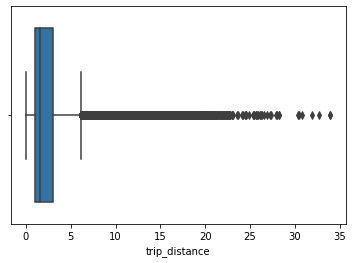

In [30]:
# Create box plot of trip_distance
box = sns.boxplot(x=df["trip_distance"], showfliers=True)

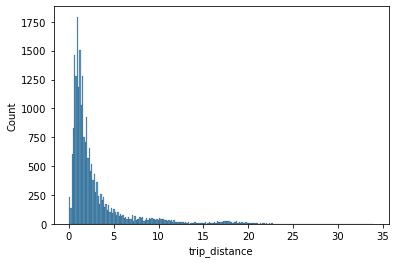

In [31]:
# Create histogram of trip_distance
hist = sns.histplot(data=df["trip_distance"])

**total amount**

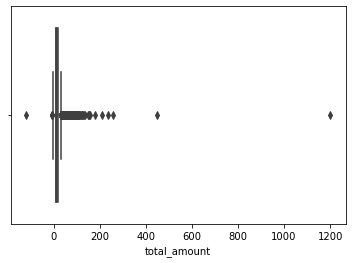

In [32]:
# Create box plot of total_amount
box = sns.boxplot(x=df["total_amount"], showfliers=True)

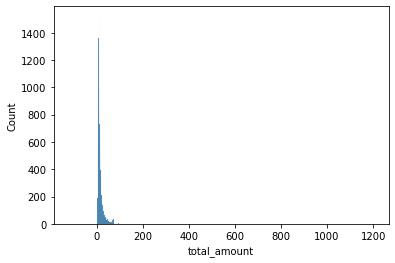

In [33]:
# Create histogram of total_amount
hist = sns.histplot(data=df["total_amount"])

**tip amount**

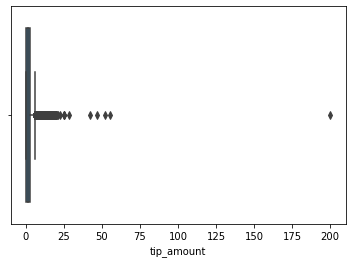

In [34]:
# Create box plot of tip_amount
box = sns.boxplot(x=df["tip_amount"], showfliers=True)

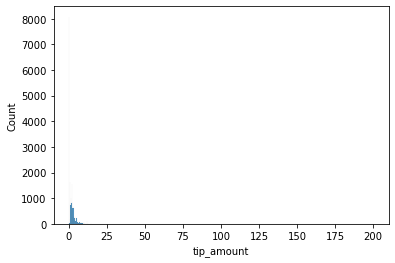

In [35]:
# Create histogram of tip_amount
hist = sns.histplot(data=df["tip_amount"])

In [36]:
sum(df["tip_amount"] == 0)

8057

**tip_amount by vendor**

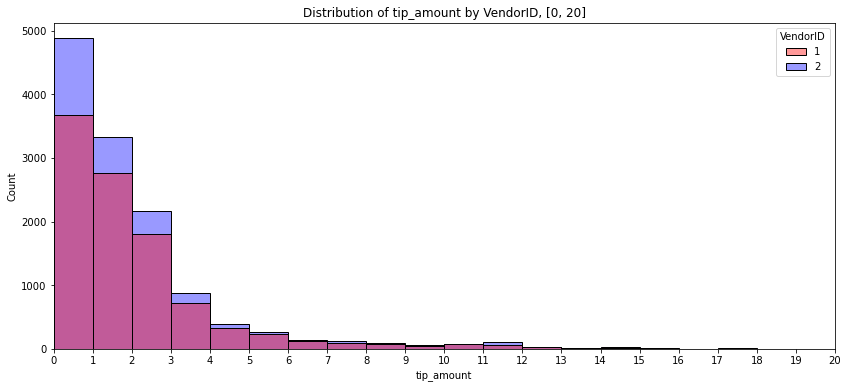

In [37]:
# Create histogram of tip_amount by vendor
plt.figure(figsize=(14, 6))
custom_palette = {
    1: 'red',
    2: 'blue'
}
bins = range(0,21,1)
ax = sns.histplot(
    data=df,
    x="tip_amount",
    bins=bins,
    hue="VendorID",
    palette=custom_palette,
    alpha=0.4,
)

plt.xlim(0, 20)
ax.set_xticks(bins)
ax.set_xticklabels(bins)
plt.title('Distribution of tip_amount by VendorID, [0, 20]')

plt.show()

In [38]:
df.groupby("VendorID")["tip_amount"].sum()

VendorID
1    18506.62
2    23163.78
Name: tip_amount, dtype: float64

Next, zoom in on the upper end of the range of tips to check whether vendor one gets noticeably more of the most generous tips.

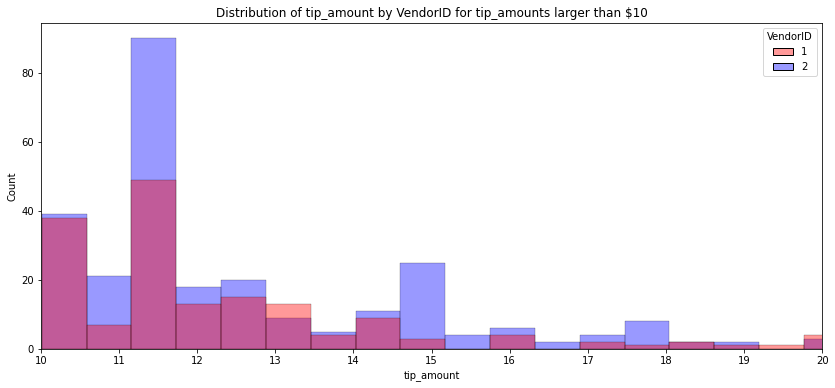

In [39]:
# Create histogram of tip_amount by vendor for tips > $10
plt.figure(figsize=(14, 6))
custom_palette = {
    1: 'red',
    2: 'blue'
}
bins = range(10,21,1)
ax = sns.histplot(
    data=df[df["tip_amount"] > 10],
    x="tip_amount",
    hue="VendorID",
    palette=custom_palette,
    alpha=0.4,
)

plt.xlim(10, 20)
ax.set_xticks(bins)
ax.set_xticklabels(bins)
plt.title('Distribution of tip_amount by VendorID for tip_amounts larger than $10')

plt.show()

**Mean tips by passenger count**

Examine the unique values in the `passenger_count` column.

In [40]:
df["passenger_count"].value_counts()

1    16117
2     3305
5     1143
3      953
6      693
4      455
0       33
Name: passenger_count, dtype: int64

In [41]:
# Calculate mean tips by passenger_count
mean_tips = (
    df.groupby("passenger_count")
      .agg(
          mean_tip=("tip_amount", "mean"),
          group_size=("tip_amount", "size")
      )
)
mean_tips

,mean_tip,group_size
passenger_count,,
0,2.135758,33
1,1.848920,16117
2,1.856378,3305
3,1.716768,953
4,1.530264,455
5,1.873185,1143
6,1.720260,693


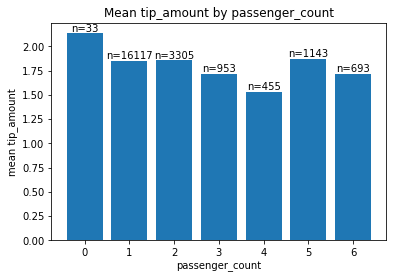

In [42]:
# Create bar plot for mean tips by passenger count
plt.bar(mean_tips.index, mean_tips["mean_tip"])

# Add labels for group size
for i, (x, y) in enumerate(zip(mean_tips.index, mean_tips["mean_tip"])):
    size = mean_tips["group_size"].iloc[i]
    plt.text(x, y, f"n={size}", ha="center", va="bottom")

plt.xlabel("passenger_count")
plt.ylabel("mean tip_amount")
plt.title("Mean tip_amount by passenger_count")

plt.show()

**Create month and day columns**

In [43]:
df["tpep_pickup_datetime"].head()

0   2017-03-25 08:55:43
1   2017-04-11 14:53:28
2   2017-12-15 07:26:56
3   2017-05-07 13:17:59
4   2017-04-15 23:32:20
Name: tpep_pickup_datetime, dtype: datetime64[ns]

In [44]:
# Create a month column
df["month"] = df["tpep_pickup_datetime"].dt.month

# Create a day column
df["day"] = df["tpep_pickup_datetime"].dt.day_name()

**Plot total ride count by month**

Begin by calculating total ride count by month.

In [45]:
# Get total number of rides for each month
rides_per_month = df.groupby("month").size()
rides_per_month

month
1     1997
2     1769
3     2049
4     2019
5     2013
6     1964
7     1697
8     1724
9     1734
10    2027
11    1843
12    1863
dtype: int64

Reorder the results to put the months in calendar order.

In [46]:
# Reorder the monthly ride list so months go in order
# Not needed

In [47]:
# Show the index
list(rides_per_month.index) == list(range(1, 13))

True

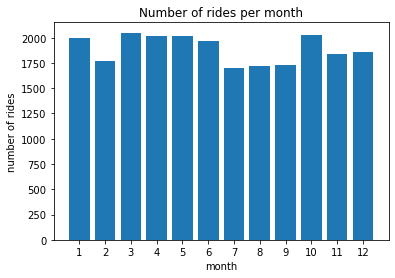

In [48]:
# Create a bar plot of total rides per month
plt.bar(rides_per_month.index, rides_per_month.values)

plt.xlabel("month")
plt.ylabel("number of rides")
plt.title("Number of rides per month")
plt.xticks(rides_per_month.index)
plt.show()

**Plot total ride count by day**

Repeat the above process, but now calculate the total rides by day of the week.

In [49]:
# Repeat the above process, this time for rides by day
rides_per_day = df.groupby("day").size()
rides_per_day

day
Friday       3413
Monday       2931
Saturday     3367
Sunday       2998
Thursday     3402
Tuesday      3198
Wednesday    3390
dtype: int64

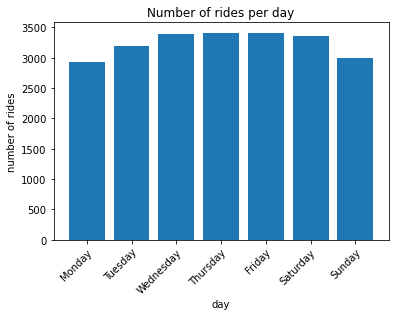

In [50]:
# Create bar plot for ride count by day
day_order = [calendar.day_name[i] for i in range(7)]
rides_per_day = rides_per_day.reindex(day_order)

plt.bar(rides_per_day.index, rides_per_day.values)

plt.xlabel("day")
plt.ylabel("number of rides")
plt.title("Number of rides per day")
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.show()

**Plot total revenue by day of the week**

Repeat the above process, but now calculate the total revenue by day of the week.

In [51]:
# Repeat the process, this time for total revenue by day
total_amount_per_day = df.groupby("day")["total_amount"].sum()
total_amount_per_day

day
Friday       55818.74
Monday       49574.37
Saturday     51195.40
Sunday       48624.06
Thursday     57181.91
Tuesday      52527.14
Wednesday    55310.47
Name: total_amount, dtype: float64

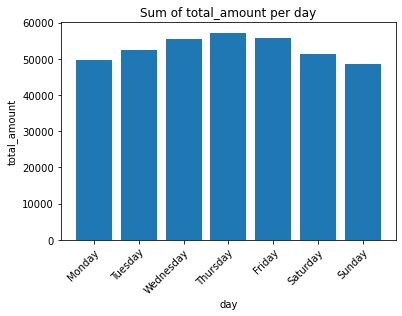

In [52]:
# Create bar plot of total revenue by day
total_amount_per_day = total_amount_per_day.reindex(day_order)

plt.bar(total_amount_per_day.index, total_amount_per_day.values)

plt.xlabel("day")
plt.ylabel("total_amount")
plt.title("Sum of total_amount per day")
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.show()

**Plot total revenue by month**

In [53]:
# Repeat the process, this time for total revenue by month
total_amount_per_month = df.groupby("month")["total_amount"].sum()
total_amount_per_month

month
1     31735.25
2     28937.89
3     33085.89
4     32012.54
5     33828.58
6     32920.52
7     26617.64
8     27759.56
9     28206.38
10    33065.83
11    30800.44
12    31261.57
Name: total_amount, dtype: float64

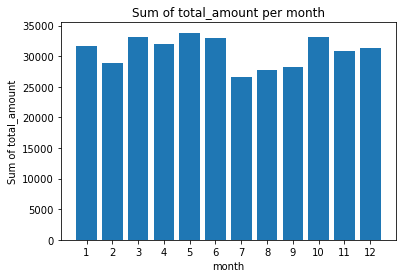

In [54]:
# Create a bar plot of total revenue by month
plt.bar(total_amount_per_month.index, total_amount_per_month.values)

plt.xlabel("month")
plt.ylabel("Sum of total_amount")
plt.title("Sum of total_amount per month")
plt.xticks(rides_per_month.index)
plt.show()

#### Scatter plot

You can create a scatterplot in Tableau Public, which can be easier to manipulate and present. If you'd like step by step instructions, you can review the following link. Those instructions create a scatterplot showing the relationship between total_amount and trip_distance. Consider adding the Tableau visualization to your executive summary, and adding key insights from your findings on those two variables.

[Tableau visualization guidelines](https://docs.google.com/document/d/1pcfUlttD2Y_a9A4VrKPzikZWCAfFLsBAhuKuomjcUjA/template/preview)

In [55]:
df["total_amount"].sort_values(ascending=False).head(20)

8476     1200.29
20312     450.30
13861     258.21
12511     233.74
15474     211.80
6064      179.06
16379     157.06
3582      152.30
11269     151.82
9280      150.30
1928      137.80
10291     131.80
6708      126.00
11608     123.30
908       121.56
7281      120.96
18130     119.31
13621     115.94
13359     111.95
29        111.38
Name: total_amount, dtype: float64

**Plot mean trip distance by drop-off location**

In [56]:
# Get number of unique drop-off location IDs
len(df["DOLocationID"].unique())

216

In [57]:
# Calculate the mean trip distance for each drop-off location
mean_dist_per_DOL = df.groupby("DOLocationID")["trip_distance"].mean()

# Sort the results in descending order by mean trip distance
mean_dist_per_DOL.sort_values(ascending=False)


DOLocationID
23     24.275000
29     21.650000
210    20.500000
11     17.945000
51     17.310000
         ...    
137     1.818852
234     1.727806
237     1.555494
193     1.390556
207     1.200000
Name: trip_distance, Length: 216, dtype: float64

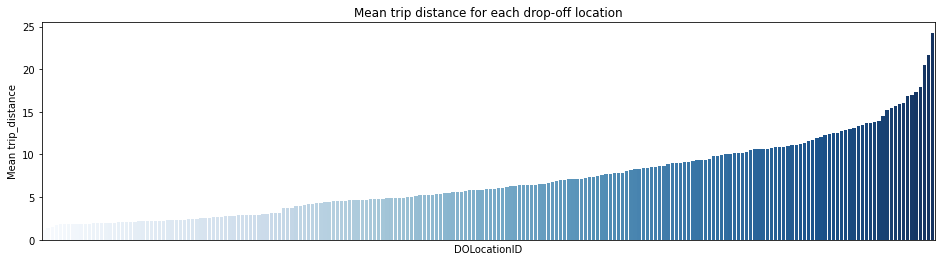

In [58]:
# Create a bar plot of mean trip distances by drop-off location in ascending order by distance

mean_dist_per_DOL = mean_dist_per_DOL.sort_values(ascending=True)

plt.figure(figsize=(16, 4))

ax = sns.barplot(
    x=mean_dist_per_DOL.index,
    y=mean_dist_per_DOL.values,
    order=mean_dist_per_DOL.index,
    palette="Blues"
)

plt.xlabel("DOLocationID")
plt.ylabel("Mean trip_distance")
plt.title("Mean trip distance for each drop-off location")
ax.set_xticklabels([])
ax.set_xticks([])
plt.show()


In [59]:
mean_dist_per_DOL.index

Int64Index([207, 193, 237, 234, 137, 100, 236, 186, 249,  34,
            ...
            183, 259,  86, 219,   1,  51,  11, 210,  29,  23],
           dtype='int64', name='DOLocationID', length=216)

## BONUS CONTENT

To confirm your conclusion, consider the following experiment:
1. Create a sample of coordinates from a normal distribution&mdash;in this case 1,500 pairs of points from a normal distribution with a mean of 10 and a standard deviation of 5
2. Calculate the distance between each pair of coordinates 
3. Group the coordinates by endpoint and calculate the mean distance between that endpoint and all other points it was paired with
4. Plot the mean distance for each unique endpoint

In [60]:
#BONUS CONTENT

# 1. Generate random points on a 2D plane from a normal distribution


# 2. Calculate Euclidean distances between points in first half and second half of array


# 3. Group the coordinates by "drop-off location", compute mean distance


# 4. Plot the mean distance between each endpoint ("drop-off location") and all points it connected to



**Histogram of rides by drop-off location**

First, check to whether the drop-off locations IDs are consecutively numbered. For instance, does it go 1, 2, 3, 4..., or are some numbers missing (e.g., 1, 3, 4...). If numbers aren't all consecutive, the histogram will look like some locations have very few or no rides when in reality there's no bar because there's no location. 

In [61]:
# Check if all drop-off locations are consecutively numbered


To eliminate the spaces in the historgram that these missing numbers would create, sort the unique drop-off location values, then convert them to strings. This will make the histplot function display all bars directly next to each other. 

In [62]:

# DOLocationID column is numeric, so sort in ascending order


# Convert to string


# Plot


<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: Execute 

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### Task 4a. Results and evaluation

Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue? 

***Pro tip:*** Put yourself in your client's perspective, what would they want to know? 

Use the following code fields to pursue any additional EDA based on the visualizations you've already plotted. Also use the space to make sure your visualizations are clean, easily understandable, and accessible. 

***Ask yourself:*** Did you consider color, contrast, emphasis, and labeling?



### **Answers**

**I have learned:**

The dataset provided contains the data needed to estimate ride fares based on key characteristics of a taxi ride (mainly trip distance and pick-up and drop-off locations).

While there are not missing values, some records do contain unexpected values for certain features. For example, there is an extreme fare amount that is without doubt a dummy value. There are records with a trip distance or passenger count of 0, as well as a few fare amounts that are negative or 0. There are also records for which the payment type is not credit card or cash, and it is not clear whether these records can be used for predicting the fare amount.

Together, these records amount to less than 2% of the whole dataset, therefore we consider that they can be removed before proceeding with modeling.

**My other questions are:**

While we have investigated some of the variables contained in the dataset, we have not done an exhaustive analysis of the fare amount itself. The analysis done on the total amount should be repeated on just the fare amount, as that is the amount that we eventually want to predict.

One aspect that was not investigated is the relationship between the amount and the RateCodeID. Does the RateCodeID have an influence on the fare amount? This question is investigated below.

While the sum of total amount was calculated per month and per day of the week, we did not investigate whether the average fare amount changes according to these time variables. This is investigated below.

Also we have not investigated whether the time of the pick-up or drop-off has any influence on the fare amount.

Finally, there are a few pick-up and drop-off locations that get most of the traffic. It would be interesting to know, just for informational purposes, where the locations are geographically located.

**My client would likely want to know:**

Is there an influence of the payment type on tips? What is the occupation rate of taxis over time and depending on location? (This might highlight the need for more or fewer taxi drivers)


In [63]:
df["RatecodeID"].value_counts()

1     22070
2       513
5        68
3        39
4         8
99        1
Name: RatecodeID, dtype: int64

Investigate only codes 1 and 2 since the others are hardly ever occurring.

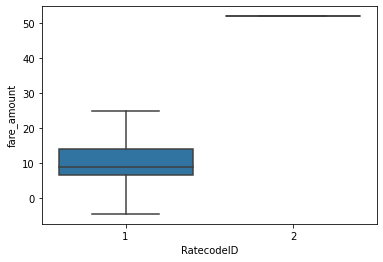

In [64]:
sns.boxplot(
    data=df[df["RatecodeID"].isin([1, 2])], 
    x="RatecodeID",
    y="fare_amount",
    showfliers=False 
);

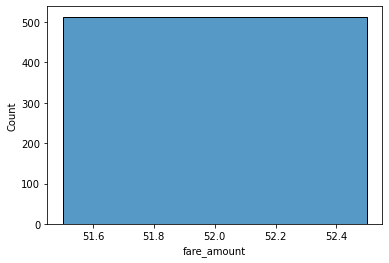

In [65]:
hist = sns.histplot(data=df[df["RatecodeID"] == 2]["fare_amount"])

In [66]:
df[df["RatecodeID"] == 2]["fare_amount"].describe()

count    513.0
mean      52.0
std        0.0
min       52.0
25%       52.0
50%       52.0
75%       52.0
max       52.0
Name: fare_amount, dtype: float64

The fare amount for the RatecodeID 2 is always 52. This seems strange and should be discussed with the client.

**Investigate the average fare according to the month**

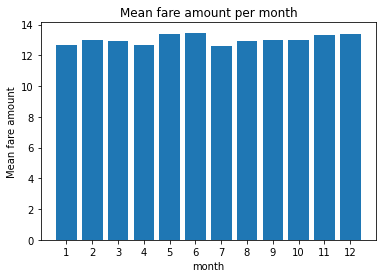

In [67]:
average_fare_per_month = df.groupby("month")["fare_amount"].mean()

plt.bar(average_fare_per_month.index, average_fare_per_month.values)

plt.xlabel("month")
plt.ylabel("Mean fare amount")
plt.title("Mean fare amount per month")
plt.xticks(average_fare_per_month.index)
plt.show()

**Investigate the average fare according to the day of week**

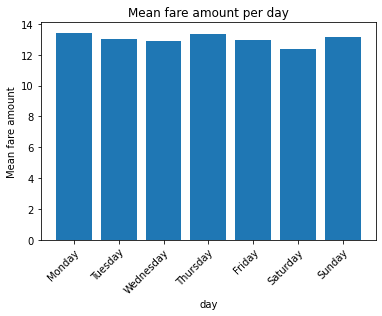

In [68]:
average_fare_per_day = df.groupby("day")["fare_amount"].mean()

average_fare_per_day = average_fare_per_day.reindex(day_order)
plt.bar(average_fare_per_day.index, average_fare_per_day.values)

plt.xlabel("day")
plt.ylabel("Mean fare amount")
plt.title("Mean fare amount per day")
plt.xticks(average_fare_per_day.index, rotation=45, ha="right", rotation_mode="anchor")
plt.show()

Based on the two bar plots above, the average fare amount does not change depending on the month or the day of the week. This means the average trip is the same over time, even though the total number of trips changes depending on these two time variables. Therefore, the day and month don't need to be considered when trying to predict the fare amount.

### Task 4b. Conclusion
*Make it professional and presentable*

You have visualized the data you need to share with the director now. Remember, the goal of a data visualization is for an audience member to glean the information on the chart in mere seconds.

*Questions to ask yourself for reflection:*
Why is it important to conduct Exploratory Data Analysis? Why are the data visualizations provided in this notebook useful?


EDA is important because ... 
it allows to uncover relationships between variables in a dataset, potentially enabling business decisions to be made. EDA also helps to identify potential issues in the data, and lead to changes in the data collection process.


Visualizations helped me understand ..
- The distribution of certain variables (trip distance, total amount, tip amount)
- The relationship between tip amount and vendor
- The relationship between tip amount and passenger count
- How the number of rides changes depending on the month and day of the week
- How the trip distance and total amount are correlated
- How the average trip distance depends on the drop-off location


You’ve now completed professional data visualizations according to a business need. Well done! 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.